<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/CODIGOFINAL/Fase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación de la fase

Esta es la fase 2 del proyecto. Lo que se hizo en esta fase fue integrar a la cohorte de los pacientes su historial clínico y los fármacos que tomaron en las primeras 48 horas de hospitalización. Para realizar esto, se fueron juntando las tablas poco a poco usando como columnas hadm_id y subject_id. Como un paciente puede tener varias hospitalizaciones y eso implicaría que salga su ID repetido, se tomó la decisión de usar sólo la última hospitalización del paciente, para que así solo salga su ID una sola vez.

# Importación y cargado de herramientas necesarias

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import matplotlib.pyplot as plt
import pandas as pd
import os

Mounted at /content/drive


In [ ]:
#Cargar los archivos de fases anteriores

OUT_DIR = "/content/drive/MyDrive/mimic_outputs"
RAW_DIR = "/content/drive/MyDrive"

base_patient = pd.read_parquet(os.path.join(OUT_DIR, "cohort_hosp_60.parquet"))
base_keys = base_patient[["subject_id", "hadm_id", "admittime"]].copy()
base_keys["admittime"] = pd.to_datetime(base_keys["admittime"], errors="coerce")

def load_raw(name, usecols=None):
    return pd.read_csv(os.path.join(RAW_DIR, f"{name}.csv.gz"),
                       compression="gzip", usecols=usecols)

diagnoses = load_raw("diagnoses_icd", usecols=["subject_id","hadm_id","seq_num","icd_code","icd_version"])
icd_dict  = load_raw("d_icd_diagnoses", usecols=["icd_code","icd_version","long_title"])
prescriptions = load_raw("prescriptions", usecols=["subject_id","hadm_id","starttime","stoptime","drug"])
icustays = load_raw("icustays", usecols=["subject_id","hadm_id","stay_id","intime","outtime"])

In [ ]:
#Comprueba que un DataFrame tenga exactamente una fila por paciente (subject_id)
#Si hay duplicados, lanza un error para detener el pipeline

#Esta función se usará en todas las demás fases
def check_unique(df, key="subject_id", name="df"):
    n_rows = len(df) #Número total de filas
    n_uniq = df[key].nunique(dropna=False) #Número de IDs únicos
    print(f"[{name}] filas={n_rows:,} | {key} únicos={n_uniq:,}")

    #1 fila = 1 paciente
    assert n_rows == n_uniq, (
        f"{name} NO es 1 fila por {key}. "
        f"Duplicados: {n_rows - n_uniq:,}"
    )
    print(f"OK: {name} es 1 fila por {key}\n")

In [ ]:
#Transformar a formato datetime para trabajar

icustays["intime"]  = pd.to_datetime(icustays["intime"], errors="coerce")
icustays["outtime"] = pd.to_datetime(icustays["outtime"], errors="coerce")

# Integración del historial clínico

In [ ]:
#Unir diagnósticos a la cohorte base usando subject_id y hadm_id

dx_idx = base_keys.merge(
    diagnoses,
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_many" #Un paciente/hospitalización puede tener múltiples diagnósticos
)

#Agregar la descripción clínica de cada código ICD usando el diccionario
dx_idx = dx_idx.merge(
    icd_dict,
    on=["icd_code", "icd_version"],
    how="left",
    validate="many_to_one" #Cada código ICD tiene una única descripción
)

#Se eliminan diagnósticos sin código ICD válido o sin descripción clínica
dx_clean = dx_idx.dropna(
    subset=["icd_code", "long_title"]
).copy()

#Verificación de tamaños antes y después de la limpieza
print("dx_idx   :", dx_idx.shape)
print("dx_clean :", dx_clean.shape)

#Vista rápida de diagnósticos clínicos limpios
dx_clean[["subject_id", "hadm_id", "icd_code", "long_title"]].head()

dx_idx   : (1595949, 7)
dx_clean : (1595872, 7)


,subject_id,hadm_id,icd_code,long_title
0,10000084,29888819,R4182,"Altered mental status, unspecified"
1,10000084,29888819,G20,Parkinson's disease
2,10000084,29888819,F0280,Dementia in other diseases classified elsewher...
3,10000084,29888819,R609,"Edema, unspecified"
4,10000084,29888819,E785,"Hyperlipidemia, unspecified"


In [ ]:
#Se cuenta el número de diagnósticos ICD distintos asociados a la hospitalización índice de cada paciente
dx_features_patient = (
    dx_clean[["subject_id", "icd_code"]]
    .drop_duplicates()              # Evita contar el mismo diagnóstico más de una vez
    .groupby("subject_id", as_index=False)
    .agg(
        n_unique_dx=("icd_code", "nunique")  # Número de diagnósticos clínicos distintos
    )
)

#Verificación del tamaño del dataset que quedó
print("dx_features_patient:", dx_features_patient.shape)

#Garantiza que el dataset esté colapsado correctamente a 1 fila por paciente
check_unique(dx_features_patient, key="subject_id", name="dx_features_patient")

#Vista rápida para ver como quedó
dx_features_patient.head()

dx_features_patient: (111045, 2)
[dx_features_patient] filas=111,045 | subject_id únicos=111,045
OK: dx_features_patient es 1 fila por subject_id



,subject_id,n_unique_dx
0,10000084,6
1,10000161,2
2,10000635,9
3,10000690,17
4,10000764,19


In [ ]:
#RX primeras 48h (índice), esto con las features por paciente

#Esto es para aegurar tipos datetime para poder filtrar correctamente en 0–48h
prescriptions["starttime"] = pd.to_datetime(prescriptions["starttime"], errors="coerce")
prescriptions["stoptime"]  = pd.to_datetime(prescriptions["stoptime"], errors="coerce")

#Unir prescripciones con la hospitalización índice para obtener el admittime y así calcular la ventana de 48h por paciente
rx_idx = prescriptions.merge(
    base_keys[["subject_id", "hadm_id", "admittime"]],
    on=["subject_id", "hadm_id"],
    how="inner",
    validate="many_to_one" #Múltiples RX por (subject_id, hadm_id), pero un único admittime en base_keys
)

#Filtrar prescripciones que inicia en las primeras 48 horas
#Se usa starttime como criterio
rx_48h = rx_idx.loc[
    rx_idx["starttime"].notna() &
    (rx_idx["starttime"] >= rx_idx["admittime"]) &
    (rx_idx["starttime"] <= rx_idx["admittime"] + pd.Timedelta(hours=48))
].copy()

print("rx_48h:", rx_48h.shape)

#Feature a nivel paciente
#Número de fármacos distintos administrados en las primeras 48h
#Se elimina duplicación para no contar el mismo medicamento más de una vez
rx_features_patient = (
    rx_48h[["subject_id", "drug"]]
    .dropna() #elimina filas sin nombre de fármaco
    .drop_duplicates() #evita sobrecontar el mismo drug dentro de un paciente
    .groupby("subject_id", as_index=False)
    .agg(n_unique_drugs_48h=("drug", "nunique"))
)

print("rx_features_patient:", rx_features_patient.shape)

#Validación para ver si queda 1 fila por subject_id
check_unique(rx_features_patient, key="subject_id", name="rx_features_patient")

#Vista rápida
rx_features_patient.head()

rx_48h: (2829425, 6)
rx_features_patient: (100360, 2)
[rx_features_patient] filas=100,360 | subject_id únicos=100,360
OK: rx_features_patient es 1 fila por subject_id



,subject_id,n_unique_drugs_48h
0,10000690,18
1,10000764,11
2,10000947,11
3,10000980,21
4,10001176,23


In [ ]:
#Último fármaco en 48h (1 por subject_id)

rx_48h_sorted = rx_48h.sort_values(["subject_id", "starttime"]).copy()

rx_last_48h_patient = (
    rx_48h_sorted
    .groupby("subject_id", as_index=False)
    .last()[["subject_id", "drug", "starttime"]]
    .rename(columns={"drug": "last_drug_48h", "starttime": "last_drug_time_48h"})
)

#Vista rápida
print("rx_last_48h_patient:", rx_last_48h_patient.shape)
check_unique(rx_last_48h_patient, key="subject_id", name="rx_last_48h_patient")
rx_last_48h_patient.head()

rx_last_48h_patient: (100360, 3)
[rx_last_48h_patient] filas=100,360 | subject_id únicos=100,360
OK: rx_last_48h_patient es 1 fila por subject_id



,subject_id,last_drug_48h,last_drug_time_48h
0,10000690,Morphine Sulfate,2152-01-30 14:00:00
1,10000764,Pravastatin,2132-10-16 20:00:00
2,10000947,Lactated Ringers,2121-05-10 11:00:00
3,10000980,Ramelteon,2193-08-17 00:00:00
4,10001176,Insulin,2186-11-30 22:00:00


In [ ]:
#ICU features por paciente (1 fila por subject_id)
icu_idx = base_keys.merge(
    icustays[["subject_id", "hadm_id", "stay_id", "intime", "outtime"]],
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_many"
)

#Flag para ver si tuvo UCI en la hospitalización índice
icu_any = (
    icu_idx[["subject_id", "stay_id"]]
    .assign(icu_any=lambda d: d["stay_id"].notna().astype(int))
    .groupby("subject_id", as_index=False)
    .agg(icu_any=("icu_any", "max"),
         n_icu_stays=("stay_id", "nunique"))
)

#LOS UCI (días) por paciente (si hay múltiples stays, suma)
icu_idx["icu_los_days"] = (
    (icu_idx["outtime"] - icu_idx["intime"]).dt.total_seconds() / (3600 * 24)
)

icu_los = (
    icu_idx.groupby("subject_id", as_index=False)
    .agg(icu_los_days=("icu_los_days", "sum"))
)

icu_features_patient = icu_any.merge(icu_los, on="subject_id", how="left", validate="one_to_one")
icu_features_patient["icu_los_days"] = icu_features_patient["icu_los_days"].fillna(0)

print("icu_features_patient:", icu_features_patient.shape)
check_unique(icu_features_patient, key="subject_id", name="icu_features_patient")
icu_features_patient.head()

icu_features_patient: (111122, 4)
[icu_features_patient] filas=111,122 | subject_id únicos=111,122
OK: icu_features_patient es 1 fila por subject_id



,subject_id,icu_any,n_icu_stays,icu_los_days
0,10000084,0,0,0.0
1,10000161,0,0,0.0
2,10000635,0,0,0.0
3,10000690,0,0,0.0
4,10000764,0,0,0.0


In [ ]:
#Integración final (1 fila por subject_id)

patient_history = (
    base_patient
    .merge(dx_features_patient, on="subject_id", how="left", validate="one_to_one")
    .merge(rx_features_patient, on="subject_id", how="left", validate="one_to_one")
    .merge(rx_last_48h_patient, on="subject_id", how="left", validate="one_to_one")
    .merge(icu_features_patient, on="subject_id", how="left", validate="one_to_one")
)

#Rellenos
patient_history["n_unique_dx"] = patient_history["n_unique_dx"].fillna(0).astype(int)
patient_history["n_unique_drugs_48h"] = patient_history["n_unique_drugs_48h"].fillna(0).astype(int)
patient_history["icu_any"] = patient_history["icu_any"].fillna(0).astype(int)
patient_history["n_icu_stays"] = patient_history["n_icu_stays"].fillna(0).astype(int)
patient_history["icu_los_days"] = patient_history["icu_los_days"].fillna(0)

print("patient_history:", patient_history.shape)
check_unique(patient_history, key="subject_id", name="patient_history")

patient_history.head()

patient_history: (111122, 18)
[patient_history] filas=111,122 | subject_id únicos=111,122
OK: patient_history es 1 fila por subject_id



,subject_id,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag,gender,anchor_age,anchor_year,admit_year,age_at_admit,n_unique_dx,n_unique_drugs_48h,last_drug_48h,last_drug_time_48h,icu_any,n_icu_stays,icu_los_days
0,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,NaT,0,M,72,2160,2160,72,6,0,NaN,NaT,0,0,0.0
1,10000161,22148160,2163-08-20 01:42:00,2163-08-20 16:33:00,NaT,0,M,60,2163,2163,60,2,0,NaN,NaT,0,0,0.0
2,10000635,20642640,2143-12-23 14:55:00,2143-12-24 12:52:00,NaT,0,F,74,2136,2143,81,9,0,NaN,NaT,0,0,0.0
3,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaT,0,F,86,2150,2152,88,17,18,Morphine Sulfate,2152-01-30 14:00:00,0,0,0.0
4,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,NaT,0,M,86,2132,2132,86,19,11,Pravastatin,2132-10-16 20:00:00,0,0,0.0


In [ ]:
#Guardar outputs

patient_history.to_parquet(
    os.path.join(OUT_DIR, "patient_history.parquet"),
    index=False
)

#Opcionales (intermedios largos)
dx_clean.to_parquet(
    os.path.join(OUT_DIR, "dx_clean_index.parquet"),
    index=False
)

rx_48h.to_parquet(
    os.path.join(OUT_DIR, "rx_48h_index.parquet"),
    index=False
)

print("Fase 2 guardada en:", OUT_DIR)

Fase 2 guardada en: /content/drive/MyDrive/mimic_outputs


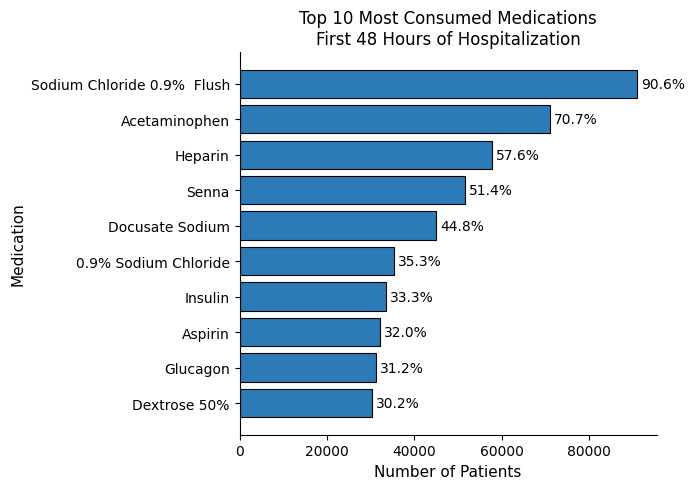

In [ ]:
#Gráfico para ver el top medicamentos más consumidos (por número de pacientes, primeras 48h)

#Cargar rx_48h (ya lo tenías)
rx_48h = pd.read_parquet(os.path.join(OUT_DIR, "rx_48h_index.parquet"))

#Top 10 medicamentos más consumidos
top_drugs = (
    rx_48h[["subject_id", "drug"]]
    .dropna()
    .drop_duplicates()
    .groupby("drug", as_index=False)
    .agg(n_patients=("subject_id", "nunique"))
    .sort_values("n_patients", ascending=False)
    .head(10)
    .sort_values("n_patients", ascending=True) #Para gráfico horizontal
)

total = rx_48h["subject_id"].nunique()
percentages = top_drugs["n_patients"] / total * 100

#Crear figura estilo paper
plt.figure(figsize=(7,5))

#Dibujar barras horizontales
bars = plt.barh(
    top_drugs["drug"],
    top_drugs["n_patients"],
    color="#2C7BB6",
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentaje al final de cada barra
for bar, pct in zip(bars, percentages):
    width = bar.get_width()
    plt.text(
        width + max(top_drugs["n_patients"])*0.01,  # un poco desplazado a la derecha
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        ha="left",
        va="center",
        fontsize=10
    )

#Configuración del gráfico
plt.xlabel("Number of Patients", fontsize=11)
plt.ylabel("Medication", fontsize=11)
plt.title(
    "Top 10 Most Consumed Medications\nFirst 48 Hours of Hospitalization",
    fontsize=12
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig("top10_medications_48h.pdf", bbox_inches="tight", facecolor="white")
plt.show()